In [1]:
import numpy as np
from PIL import Image

In [4]:
image = Image.open('/home/asenella/dev/multivae_package/Stop.png')

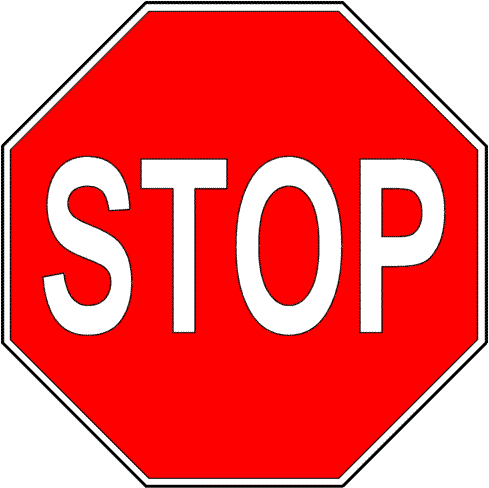

In [5]:
image

[ 0 42]
[  0  51 127 136 255]
[  0  51 102 153 204 255]


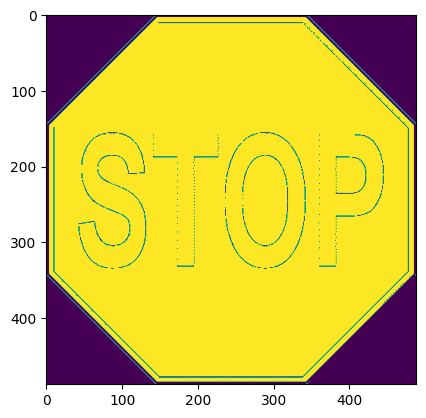

In [48]:
hsv = image.convert('HSV')
hsv = np.array(hsv)[:, :, :].copy()
print(np.unique(hsv[:,:,0]))
print(np.unique(hsv[:,:,1]))
print(np.unique(hsv[:,:,2]))

plt.imshow(np.logical_and(hsv[:,:,0]< 15,hsv[:,:,2]>= 70, hsv[:,:,1]>= 50))

In [65]:
def in_range(hsv, lower, upper):
    mask_h = np.logical_and(hsv[:,:,0] >= lower[0], hsv[:,:,0] <= upper[0])
    mask_s = np.logical_and(hsv[:,:,1] >= lower[1] , hsv[:,:,1] <= upper[1])
    mask_v = np.logical_and(hsv[:,:,2] >= lower[2] , hsv[:,:,2] <= upper[2])
    
    return mask_h & mask_s & mask_v



def count_pixels_per_color(hsv_image):
    
    color_ranges = dict(
        white = lambda h : in_range(h,[0,0,120],[180,18,255]),
        yellow = lambda h : in_range(h,[25,50,70],[35,255,255]),
        blue = lambda h : in_range(h,[90,50,70],[158,255,255]),
        green = lambda h: in_range(h,[36, 50, 70],[89, 255, 255]),
        gray = lambda h: in_range(h,[0, 0, 50],[180, 18, 120]),
        brown = lambda h: in_range(h,[16, 50, 70],[24, 255, 255]),
        black = lambda h: in_range(h,[0, 0, 0],[180, 255, 50]),
        red = lambda h: np.logical_or(in_range(h,[0, 50, 70],[15, 255, 255]), in_range(h,[159, 50, 70],[180, 255, 255]))
    )
    
    color_masks = dict()
    color_count = dict()
    for color in color_ranges:
        color_masks[color] = color_ranges[color](hsv_image)
        color_count[color] = color_masks[color].sum()
        
    # get the two most present colors :
    
    values = np.sort(list(color_count.values()))[-2:]
    
    most_present = [color for color in color_count if color_count[color] in values]
        
    return color_masks, color_count, most_present

In [66]:
ct = count_pixels_per_color(hsv)

(488, 489)
[False  True]


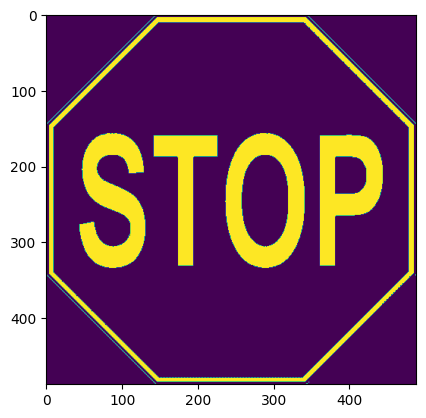

In [67]:
import matplotlib.pyplot as plt

plt.imshow(ct[0]['white'])

print(ct[0]['white'].shape)

print(np.unique(ct[0]['white']))


In [68]:
ct[2]

['red']